# LeetCode #192: Word Frequency

https://leetcode.com/problems/word-frequency/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| awk + sort ★ | O(n log n) | O(n) |
| tr + sort + uniq | O(n log n) | O(n) |

## Understanding the Methods
### awk + sort (Optimal Shell)
Use awk to split each line into words, count frequency with an associative array, then pipe to sort. This is the idiomatic shell approach.

### tr + sort + uniq
Translate spaces to newlines, sort, count with `uniq -c`, then sort by frequency descending. More pipes but equally valid.

## Solutions

### C#

In [ ]:
// Shell Problem — Bash solution:
// cat words.txt | tr -s ' ' '\n' | sort | uniq -c | sort -rn | awk '{print $2, $1}'
//
// Alternative using awk:
// awk '{for(i=1;i<=NF;i++) freq[$i]++} END{for(w in freq) print w, freq[w]}' words.txt | sort -k2 -rn

// C# equivalent:
using System;
using System.Collections.Generic;
using System.IO;
using System.Linq;

var freq = new Dictionary<string, int>();
foreach (var line in File.ReadAllLines("words.txt")) {
    foreach (var word in line.Split(' ', StringSplitOptions.RemoveEmptyEntries)) {
        freq[word] = freq.GetValueOrDefault(word) + 1;
    }
}
foreach (var kv in freq.OrderByDescending(kv => kv.Value)) {
    Console.WriteLine($"{kv.Key} {kv.Value}");
}

### Python

In [ ]:
from collections import Counter

def word_frequency(filename: str) -> list[tuple[str, int]]:
    with open(filename) as f:
        words = f.read().split()
    counts = Counter(words)
    return counts.most_common()

# Usage:
# for word, count in word_frequency('words.txt'):
#     print(f'{word} {count}')

### Go

In [ ]:
package main

import (
    "bufio"
    "fmt"
    "os"
    "sort"
    "strings"
)

func main() {
    freq := make(map[string]int)
    scanner := bufio.NewScanner(os.Stdin)
    for scanner.Scan() {
        for _, word := range strings.Fields(scanner.Text()) {
            freq[word]++
        }
    }
    type wc struct {
        word  string
        count int
    }
    var pairs []wc
    for w, c := range freq {
        pairs = append(pairs, wc{w, c})
    }
    sort.Slice(pairs, func(i, j int) bool {
        return pairs[i].count > pairs[j].count
    })
    for _, p := range pairs {
        fmt.Printf("%s %d\n", p.word, p.count)
    }
}

### Rust

In [ ]:
use std::collections::HashMap;
use std::io::{self, Read};

fn main() {
    let mut input = String::new();
    io::stdin().read_to_string(&mut input).unwrap();
    
    let mut freq: HashMap<&str, usize> = HashMap::new();
    for word in input.split_whitespace() {
        *freq.entry(word).or_insert(0) += 1;
    }
    
    let mut pairs: Vec<_> = freq.into_iter().collect();
    pairs.sort_by(|a, b| b.1.cmp(&a.1));
    
    for (word, count) in pairs {
        println!("{} {}", word, count);
    }
}

## Examples

**1. Common Case — Straightforward Counting**
**Input:** File contains `"the day is sunny the the\nthe sunny is is"`
Scan each word and tally: "the" appears 4 times, "is" 3 times, "sunny" 2 times, "day" once. Sort descending by frequency.
*Why tricky:* Baseline test — verifies basic word splitting across newlines. Total words $W = 8$, unique $U = 4$, time $O(W + U \log U)$.

**2. Slightly Complex — Tied Frequencies**
**Input:** File contains `"i love coding\ni love coding\ni love leetcode"`
"i" and "love" both appear 3 times, "coding" 2 times, "leetcode" once. When frequencies tie, any ordering among tied words is valid.
*Why tricky:* Tied counts expose sort-stability assumptions. With $U = 4$ unique words, the sort must handle equal keys without crashing or reordering unpredictably.

**3. Edge Case: Time Factor — Large File (500K words)**
**Input:** 10,000 lines, 50 words per line → $W = 500{,}000$ total words, $\sim$1,000 unique
awk scans all $W$ words in $O(W)$. Sorting 1,000 unique words costs $O(U \log U) = O(1000 \times 10) \approx 10{,}000$ comparisons. Total: $O(W + U \log U)$.
*Why tricky:* Worst-case time — the scan phase dominates. The sort is on unique count $U$, not total words $W$.

**4. Edge Case: Space Factor — All Words Unique**
**Input:** 10,000 lines each containing one distinct word → $W = U = 10{,}000$
Every word is unique, so the associative array stores all 10,000 entries. Space $= O(U) = O(W)$. This is the worst case: $U = W$.
*Why tricky:* Worst-case memory — when every word is unique, the hash map grows linearly. $O(W)$ memory with no compression.

**5. Almost-Impossible but Plausible — Single Word Repeated 10⁶ Times**
**Input:** File contains `"a"` repeated 1,000,000 times across many lines
Only one unique word. Hash map has 1 entry, count $= 10^6$. Sort is $O(1)$. Boundary: count fits in 32-bit int ($\max = 2^{31}-1 \approx 2.1 \times 10^9$). No overflow.
*Why tricky:* Extreme skew — degenerate sort (1 element), counter near-overflow test. Verifies $10^6 < 2^{31}-1$.

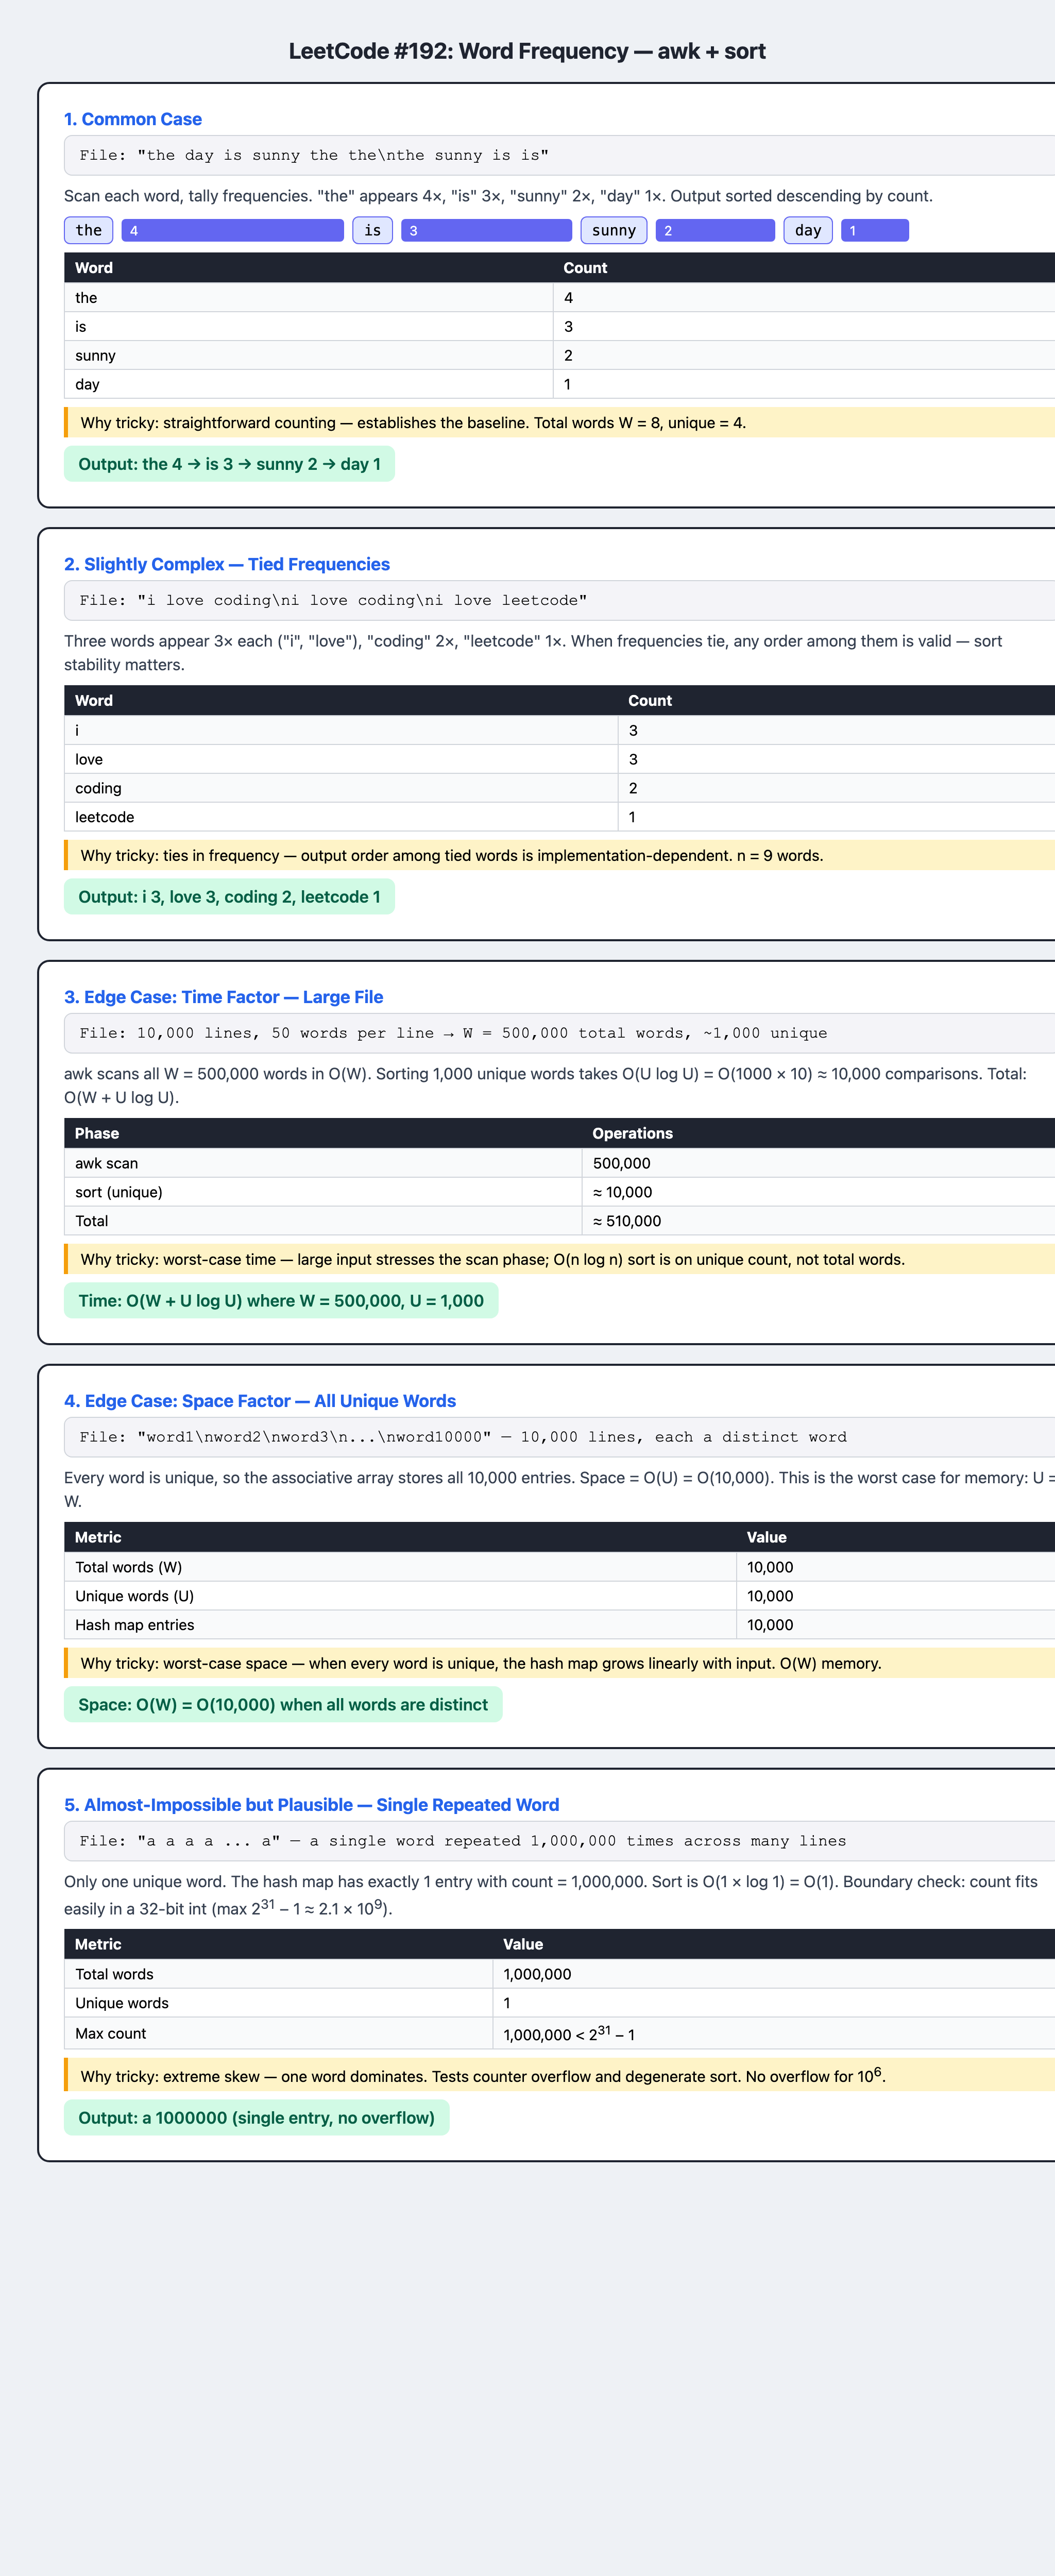